In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipynbname
import os

In [2]:
notebook_path = ipynbname.path()
notebook_dir = os.path.dirname(notebook_path)

# 1. Import data and define variables

Data collection was done in November 2025; it included data from different sources:

- Register of Buildings and Dwellings (https://www.housing-stat.ch/it/madd/public.html#scaricare_i_dati) --> has data of building properties and heating technology
- Electricity production plants (https://www.geocat.ch/geonetwork/srv/ita/catalog.search#/metadata/e5a00bdb-5022-4856-ad4a-d1afe7bf38b0) --> has the data related to all production plants actually installed in Switzerland
- Suitability of roofs for the use of solar energy (https://www.geocat.ch/geonetwork/srv/eng/catalog.search#/metadata/b614de5c-2f12-4355-b2c9-7aef2c363ad6)
- Cadastral data (https://www.geocat.ch/geonetwork/srv/eng/catalog.search#/metadata/a3c0f7fb-1be0-4385-9c54-33b65ae3e1ae) --> has the shapefiles of each infrastructure in Switzerland. These data is not available for all the Cantons.

The output of the first data collection is one unique dataframe that contains for each residential building in Switzerland the data related to its properties, heating technology, PV plant presence and shape (for the Cantons with open cadastral data available) - here named 'gdf_input'.

In [3]:
gdf_file = '/data/gdf_input.gpkg'

gdf_raw = gpd.read_file(notebook_dir + gdf_file)
gdf = gdf_raw.to_crs(epsg=2056)

In [4]:
gdf[['GKLAS', 'GBAUP', 'GWAERZH1', 'GWAERZH2', 'GWAERZW1', 'GENH1', 'GENH2', 'GENW1']] = gdf[['GKLAS', 'GBAUP', 'GWAERZH1', 'GWAERZH2', 'GWAERZW1', 'GENH1', 'GENH2', 'GENW1']].fillna(0)

In [5]:
gdf["Type"] = gdf["GKLAS"].map({1110: "SFH", 1121: "DFH", 1122: "MFH"}).fillna("No Info")
gdf["Construction Period"] = pd.cut(gdf["GBAUP"], bins=[-float("inf"), 8011, 8012, 8013, 8014, 8015, 8017, 8019, 8021, float("inf")],
                                    labels=["< 1920", "1921-1945", "1946-1960", "1961-1970", "1971-1980", "1981-1990", "1991-2000", "2001-2010", "> 2010"])
gdf["Gen_SH"] = pd.cut(gdf["GWAERZH1"], bins=[-float("inf"), 1, 7400, 7411, 7421, 7435, 7436, 7441, 7452, 7461, float("inf")],
                       labels=["", "No_Heating", "HP", "ST", "Boiler", "Heater", "Cogeneration", "EH", "DH", "Indeterminate"])
gdf["Gen_SH2"] = pd.cut(gdf["GWAERZH2"], bins=[-float("inf"), 1, 7400, 7411, 7421, 7435, 7436, 7441, 7452, 7461, float("inf")],
                       labels=["", "No_Heating", "HP", "ST", "Boiler", "Heater", "Cogeneration", "EH", "DH", "Indeterminate"])
gdf["Gen_DHW"] = pd.cut(gdf["GWAERZW1"], bins=[-float("inf"), 1, 7600, 7610, 7620, 7634, 7640, 7651, float("inf")],
                        labels=["", "No_Heating", "HP", "ST", "Boiler", "Cogeneration", "EH", "Indeterminate"])
gdf["Energy_SH"] = pd.cut(gdf["GENH1"], bins=[-float("inf"), 1, 7500, 7501, 7512, 7513, 7520, 7530, 7543, 7560, 7570, 7582, float("inf")],
                          labels=["", "No_Heating", "Aria", "Geothermic", "Water", "Gas_Boiler", "Oil_Boiler", "Wood_Boiler", "EH", "ST", "DH", "Indeterminate"])
gdf["Energy_SH2"] = pd.cut(gdf["GENH2"], bins=[-float("inf"), 1, 7500, 7501, 7512, 7513, 7520, 7530, 7543, 7560, 7570, 7582, float("inf")],
                          labels=["", "No_Heating", "Aria", "Geothermic", "Water", "Gas_Boiler", "Oil_Boiler", "Wood_Boiler", "EH", "ST", "DH", "Indeterminate"])
gdf["Energy_DHW"] = pd.cut(gdf["GENW1"], bins=[-float("inf"), 1, 7500, 7501, 7512, 7513, 7520, 7530, 7543, 7560, 7570, 7582, float("inf")],
                           labels=["", "No_Heating", "Aria", "Geothermic", "Water", "Gas_Boiler", "Oil_Boiler", "Wood_Boiler", "EH", "ST", "DH", "Indeterminate"])

In [6]:
gdf["Tech_SH"] = np.where(gdf["Gen_SH"].isin(["HP", "Cogeneration", "ST", "EH", "No_Heating", "DH"]), gdf["Gen_SH"], gdf["Energy_SH"])
gdf["Tech_SH2"] = np.where(gdf["Gen_SH2"].isin(["HP", "Cogeneration", "ST", "EH", "No_Heating", "DH"]), gdf["Gen_SH2"], gdf["Energy_SH2"])
gdf["Tech_DHW"] = np.where(gdf["Gen_DHW"].isin(["HP", "Cogeneration", "ST", "EH", "No_Heating", "DH"]), gdf["Gen_DHW"], gdf["Energy_DHW"])

gdf["Heating_SH"] = np.where(
    gdf["Tech_SH"] == gdf["Tech_SH2"], gdf["Tech_SH"],
    gdf["Tech_SH"] + "_&_" + gdf["Tech_SH2"])

gdf["Heating_Tech"] = (
    np.where(gdf["Heating_SH"].isin(["HP_&_Oil_Boiler", "HP_&_Gas_Boiler", "Gas_Boiler_&_ST", "Oil_Boiler_&_ST", "HP_&_ST", "Wood_Boiler_&_ST"]), gdf["Heating_SH"],
    np.where(gdf["Tech_SH"].isin(["Indeterminate", "No_Heating", ""]), gdf["Tech_DHW"],
    np.where(gdf["Tech_SH"] == gdf["Tech_DHW"], gdf["Tech_SH"], gdf["Tech_SH"] + "_&_" + gdf["Tech_DHW"]))))

In [7]:
tech_simplification_map = {
    'Oil': ["Oil_Boiler", "Oil_Boiler_&_", "Oil_Boiler_&_Gas_Boiler", "Oil_Boiler_&_Wood_Boiler", "Oil_Boiler_&_DH", "Oil_Boiler_&_EH", "Oil_Boiler_&_Geothermic", "Indeterminate_&_Oil_Boiler", "Oil_Boiler_&_Indeterminate", "Oil_Boiler_&_No_Heating", 'Oil_Boiler_&_Cogeneration', "Oil_Boiler_&_HP", "Oil_Boiler_&_Aria", 'Oil_Boiler_&_Water'],

    'Gas': ["Gas_Boiler", "Gas_Boiler_&_", "Gas_Boiler_&_Oil_Boiler", "Gas_Boiler_&_Wood_Boiler", "Gas_Boiler_&_DH", "Gas_Boiler_&_EH", "Indeterminate_&_Gas_Boiler", "Gas_Boiler_&_Indeterminate", "Gas_Boiler_&_No_Heating", "Gas_Boiler_&_HP", "Gas_Boiler_&_Aria", 'Cogeneration_&_Gas_Boiler'],

    'Wood': ["Wood_Boiler", "Wood_Boiler_&_", "Wood_Boiler_&_Gas_Boiler", "Wood_Boiler_&_HP", "Wood_Boiler_&_Oil_Boiler", "Wood_Boiler_&_DH", "Wood_Boiler_&_EH", "Wood_Boiler_&_Aria", "Wood_Boiler_&_Geothermic", "Wood_Boiler_&_Water", "Wood_Boiler_&_Cogeneration", "Indeterminate_&_Wood_Boiler", "Wood_Boiler_&_No_Heating", "Wood_Boiler_&_Indeterminate"],

    'HeatPump': ["HP_&_Wood_Boiler", "HP_&_", "HP_&_DH", "HP_&_EH", "HP_&_Cogeneration", "Aria_&_Wood_Boiler", "HP_&_Water", "Aria", "Aria_&_HP", "HP_&_Geothermic", "HP_&_Aria", "Indeterminate_&_HP", "HP_&_Indeterminate", "HP_&_No_Heating", "Water", "Aria_&_Indeterminate", 'HP', "HP_&_Oil_Boiler", "Aria_&_Oil_Boiler", "HP_&_Gas_Boiler", "Aria_&_Gas_Boiler"],

    'ElectricHeater': ["EH_&_HP", "EH_&_", "EH_&_ST", "EH_&_Oil_Boiler", "EH_&_Gas_Boiler", "EH_&_Wood_Boiler", "EH_&_DH", "DH_&_Geothermic", "EH_&_Water", "EH_&_Cogeneration", "Water_&_EH", "Aria_&_EH", "Indeterminate_&_EH", "EH_&_Indeterminate", "EH_&_No_Heating", 'EH'],

    'DH': ["DH_&_Oil_Boiler", "DH_&_", "ST_&_", "DH_&_EH", "DH_&_Wood_Boiler", "DH_&_Gas_Boiler", "DH_&_HP", "DH_&_ST", "DH_&_Cogeneration", "Geothermic_&_ST", "Geothermic_&_Wood_Boiler", "Cogeneration_&_HP", "Geothermic_&_EH", "Cogeneration_&_EH", "Geothermic_&_HP", "Indeterminate_&_DH", "ST_&_EH", "ST_&_HP", "DH_&_Indeterminate", "ST_&_Wood_Boiler", "ST_&_Oil_Boiler", "ST_&_Indeterminate", "DH_&_No_Heating", "ST_&_Gas_Boiler", "Geothermic", "Cogeneration", "ST_&_DH", "Geothermic_&_Indeterminate", "ST_&_No_Heating", "Geothermic_&_Oil_Boiler", "Cogeneration_&_Indeterminate","Cogeneration_&_Wood_Boiler", "Geothermic_&_Gas_Boiler", "Cogeneration_&_Oil_Boiler", "ST", 'Geothermic_&_No_Heating', 'Water_&_DH', 'ST_&_Geothermic', 'DH'],

    'No info': ["Indeterminate_&_Geothermic", "Indeterminate_&_Water", "Indeterminate_&_Aria", "Indeterminate", ""],

    'No heating': ["No_Heating_&_Aria", "No_Heating_&_DH", "No_Heating_&_HP", "No_Heating_&_ST", "No_Heating_&_Oil_Boiler", "No_Heating_&_Wood_Boiler", "No_Heating_&_Gas_Boiler", "No_Heating_&_EH", "No_Heating"],

    'HPST': ["HP_&_ST", "Aria_&_ST"],

    'GasST': ["Gas_Boiler_&_ST"],

    'WoodST': ["Wood_Boiler_&_ST"],

    'OilST': ["Oil_Boiler_&_ST"]
}

In [8]:
def simplify_heating_tech(tech):
    for key, values in tech_simplification_map.items():
        if tech in values:
            return key
    return tech

In [9]:
gdf["Heating Technology"] = gdf["Heating_Tech"].apply(simplify_heating_tech)
gdf['PV'] = np.where(gdf['TotalPower'] > 0, 'PVyes', 'PVno')
gdf['PV power'] = np.where(gdf['TotalPower'] > 0, gdf['TotalPower'], 0)
gdf['PV power'] = gdf['PV power'].astype(float)

In [10]:
pd.set_option('future.no_silent_downcasting', True)
gdf["Initial operation Heating"] = np.where(gdf["Construction Period"] == "> 2010", gdf["GBAUJ"], pd.to_datetime(gdf["GWAERDATH1"], errors='coerce').dt.year)

gdf["Initial operation PV"] = np.where(gdf["BeginningOfOperation"] != 0, pd.to_datetime(gdf["BeginningOfOperation"], errors='coerce').dt.year, gdf["BeginningOfOperation"])
gdf['Initial operation PV'] = gdf['Initial operation PV'].fillna(0)
gdf['Initial operation PV'] = gdf['Initial operation PV'].astype(float)

gdf["Reference Area [m2]"] = np.where(gdf["GEBF"] > 0, gdf["GEBF"], 0)
gdf['Specific Roof Potential [kWh/m2y]'] = gdf['STROMERTRAG'] / gdf['FLAECHE']

In [11]:
gdf["Area [m2]"] = np.where(gdf["Reference Area [m2]"] > 0,
                            gdf["Reference Area [m2]"],
                            gdf["GAREA"] * gdf["GASTW"])

In [12]:
gdf = gdf.drop(columns=['EGID', 'OBJID', 'R1_OBJID', 'GKODE', 'GKODN', 'GSTAT', 'GKAT', 'GKLAS', 'GBAUP', 'GAREA', 'GASTW', 'GANZWHG', 'GEBF', 'GWAERZH1', 'GWAERZH2', 'GENH1', 'GENH2', 'GWAERDATH1', 'GWAERZW1', 'GENW1', 'GWAERSCEW1', 'BeginningOfOperation', 'TotalPower', 'Gen_SH', 'Gen_SH2', 'Gen_DHW', 'Energy_SH', 'Energy_SH2', 'Energy_DHW', 'Tech_SH', 'Tech_SH2', 'Tech_DHW', 'Heating_Tech', 'Heating_SH', "Reference Area [m2]", 'R1_EGRIS_E', 'GBAUJ', 'GWAERSCEH1', 'STROMERTRAG', 'STROMERTRAG_SOMMERHALBJAHR', 'STROMERTRAG_WINTERHALBJAHR', 'PV power', 'Initial operation Heating', 'Initial operation PV'])
gdf = gdf.rename(columns={'GDEKT': 'Canton',
                          'GGDENAME': 'Municipality',
                          'FLAECHE': 'Roof area [m2]'})

# 2. Add adoption drivers

Add all the possible drivers to be used to describe PV and HP adoption. When the data is not available, the average over Switzerland is assumed.

In [13]:
gdf_2025_drivers = gdf.copy()

In [14]:
if gdf_2025_drivers.geom_type.isin(["Polygon", "MultiPolygon"]).any():
    gdf_2025_drivers["geometry"] = gdf_2025_drivers.centroid

In [15]:
shp_file_district_limits = 'swissBOUNDARIES3D_1_5_TLM_BEZIRKSGEBIET.shp'

district_limits = gpd.read_file(notebook_dir + '/data/Limits/' + shp_file_district_limits)
district_limits = district_limits[['NAME', 'geometry']]
district_limits = district_limits.dissolve(by="NAME", as_index=False)

shp_file_cantonal_limits = 'swissBOUNDARIES3D_1_4_TLM_KANTONSGEBIET.shp'

cantonal_limits = gpd.read_file(notebook_dir + '/data/Limits/' + shp_file_cantonal_limits)
cantonal_limits = cantonal_limits[['NAME', 'geometry']]
cantonal_limits = cantonal_limits.dissolve(by="NAME", as_index=False)
cantonal_limits = cantonal_limits.loc[cantonal_limits['NAME'].isin(['Genève', 'Basel-Stadt', 'Zug', 'Uri', 'Appenzell Innerrhoden', 'Nidwalden', 'Obwalden', 'Glarus', 'Neuchâtel'])].copy()

limits = pd.concat([district_limits, cantonal_limits])
limits = limits.to_crs(epsg=2056)

In [16]:
gdf_2025_drivers = gdf_2025_drivers.sjoin(limits, predicate='within', how='left')
gdf_2025_drivers = gdf_2025_drivers.drop(columns=['index_right'])
gdf_2025_drivers = gdf_2025_drivers.rename(columns={'NAME': 'District'})
gdf_2025_drivers = gdf_2025_drivers.to_crs(epsg=2056)

In [17]:
print(len(gdf_2025_drivers))
gdf_2025_drivers = gdf_2025_drivers.loc[gdf_2025_drivers.geometry.is_valid].copy()
print(len(gdf_2025_drivers))
gdf_2025_drivers = gdf_2025_drivers.loc[~gdf_2025_drivers['District'].isna()].copy()
print(len(gdf_2025_drivers))
gdf_2025_drivers = gdf_2025_drivers.loc[~gdf_2025_drivers['Area [m2]'].isna()].copy()
gdf_2025_drivers = gdf_2025_drivers.loc[~gdf_2025_drivers['Roof area [m2]'].isna()].copy()
print(len(gdf_2025_drivers))

1724870
1715249
1715247
1684337


In [18]:
ev_share_file = '/data/Drivers/share_EVs_mun.csv'

df_ev_share_raw = pd.read_csv(
    notebook_dir + ev_share_file,
    sep=";",
    skiprows=3,
    names=["Municipality", "EV share [%]"]
)

df_ev_share_raw["EV share [%]"] = pd.to_numeric(df_ev_share_raw["EV share [%]"], errors="coerce")

gdf_2025_drivers = gdf_2025_drivers.merge(
    df_ev_share_raw,
    how="left",
    on="Municipality"
)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["EV share [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

mean = gdf_2025_drivers["EV share [%]"].mean()
gdf_2025_drivers["EV share [%]"] = gdf_2025_drivers["EV share [%]"].fillna(mean)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["EV share [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

Municipalities not matched: 5
Municipalities not matched: 0


In [19]:
second_house_file = '/data/Drivers/secondary_house_rate_mun.gpkg'

gdf_second_house = gpd.read_file(notebook_dir + second_house_file)

df_second_house = (gdf_second_house
               .loc[:, ["Name", "ZWG_3120"]]
               .rename(columns={"Name": "Municipality",
                                "ZWG_3120": "Secondary House Rate [%]"})
              )

gdf_2025_drivers = gdf_2025_drivers.merge(
    df_second_house,
    how="left",
    on="Municipality"
)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["Secondary House Rate [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

mean = gdf_2025_drivers["Secondary House Rate [%]"].mean()
gdf_2025_drivers["Secondary House Rate [%]"] = gdf_2025_drivers["Secondary House Rate [%]"].fillna(mean)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["Secondary House Rate [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

Municipalities not matched: 5
Municipalities not matched: 0


In [20]:
people_over65_file = '/data/Drivers/people_over_65_mun.csv'

df_people_over65 = pd.read_csv(
    notebook_dir + people_over65_file,
    sep=";",
    skiprows=3,
    names=["Municipality", "People Over 65 [%]"]
)

df_people_over65["People Over 65 [%]"] = pd.to_numeric(df_people_over65["People Over 65 [%]"], errors="coerce")

df_people_over65 = df_people_over65[[ "Municipality", "People Over 65 [%]"]].copy()

gdf_2025_drivers = gdf_2025_drivers.merge(
    df_people_over65,
    how="left",
    on="Municipality"
)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["People Over 65 [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

mean = gdf_2025_drivers["People Over 65 [%]"].mean()
gdf_2025_drivers["People Over 65 [%]"] = gdf_2025_drivers["People Over 65 [%]"].fillna(mean)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["People Over 65 [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

Municipalities not matched: 4
Municipalities not matched: 0


In [21]:
people_over80_file = '/data/Drivers/people_over_80_mun.csv'

df_people_over80 = pd.read_csv(
    notebook_dir + people_over80_file,
    sep=";",
    skiprows=3,
    names=["Municipality", "People Over 80 [%]"]
)

df_people_over80["People Over 80 [%]"] = pd.to_numeric(df_people_over80["People Over 80 [%]"], errors="coerce")

df_people_over80 = df_people_over80[[ "Municipality", "People Over 80 [%]"]].copy()

gdf_2025_drivers = gdf_2025_drivers.merge(
    df_people_over80,
    how="left",
    on="Municipality"
)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["People Over 80 [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

mean = gdf_2025_drivers["People Over 80 [%]"].mean()
gdf_2025_drivers["People Over 80 [%]"] = gdf_2025_drivers["People Over 80 [%]"].fillna(mean)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["People Over 80 [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

Municipalities not matched: 13
Municipalities not matched: 0


In [22]:
people_below19_file = '/data/Drivers/people_below_19_mun.csv'

df_people_below19 = pd.read_csv(
    notebook_dir + people_below19_file,
    sep=";",
    skiprows=3,
    names=["Municipality", "People Below 19 [%]"]
)

df_people_below19["People Below 19 [%]"] = pd.to_numeric(df_people_below19["People Below 19 [%]"], errors="coerce")

df_people_below19 = df_people_below19[[ "Municipality", "People Below 19 [%]"]].copy()

gdf_2025_drivers = gdf_2025_drivers.merge(
    df_people_below19,
    how="left",
    on="Municipality"
)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["People Below 19 [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

mean = gdf_2025_drivers["People Below 19 [%]"].mean()
gdf_2025_drivers["People Below 19 [%]"] = gdf_2025_drivers["People Below 19 [%]"].fillna(mean)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["People Below 19 [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

Municipalities not matched: 6
Municipalities not matched: 0


In [23]:
households_over5people_file = '/data/Drivers/households_over5people_mun.csv'

df_households_over5people = pd.read_csv(
    notebook_dir + households_over5people_file,
    sep=";",
    skiprows=3,
    names=["Municipality", "Households Over 5 People [%]"]
)

df_households_over5people["Households Over 5 People [%]"] = pd.to_numeric(df_households_over5people["Households Over 5 People [%]"], errors="coerce")

df_households_over5people = df_households_over5people[[ "Municipality", "Households Over 5 People [%]"]].copy()

gdf_2025_drivers = gdf_2025_drivers.merge(
    df_households_over5people,
    how="left",
    on="Municipality"
)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["Households Over 5 People [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

mean = gdf_2025_drivers["Households Over 5 People [%]"].mean()
gdf_2025_drivers["Households Over 5 People [%]"] = gdf_2025_drivers["Households Over 5 People [%]"].fillna(mean)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["Households Over 5 People [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

Municipalities not matched: 4
Municipalities not matched: 0


In [24]:
foreigners_share_file = '/data/Drivers/foreigners_share_mun.csv'

df_foreigners_share = pd.read_csv(
    notebook_dir + foreigners_share_file,
    sep=";",
    skiprows=3,
    names=["Municipality", "Foreigners Share [%]"]
)

df_foreigners_share["Foreigners Share [%]"] = pd.to_numeric(df_foreigners_share["Foreigners Share [%]"], errors="coerce")

df_foreigners_share = df_foreigners_share[[ "Municipality", "Foreigners Share [%]"]].copy()

gdf_2025_drivers = gdf_2025_drivers.merge(
    df_foreigners_share,
    how="left",
    on="Municipality"
)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["Foreigners Share [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

mean = gdf_2025_drivers["Foreigners Share [%]"].mean()
gdf_2025_drivers["Foreigners Share [%]"] = gdf_2025_drivers["Foreigners Share [%]"].fillna(mean)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["Foreigners Share [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

Municipalities not matched: 13
Municipalities not matched: 0


In [25]:
CO2Act_file = '/data/Drivers/CO2Act_yes_mun.csv'

df_CO2Act = pd.read_csv(
    notebook_dir + CO2Act_file,
    sep=";",
    skiprows=3,
    names=["Municipality", "CO2Act Yes Share [%]"]
)

df_CO2Act["CO2Act Yes Share [%]"] = pd.to_numeric(df_CO2Act["CO2Act Yes Share [%]"], errors="coerce")

df_CO2Act = df_CO2Act[[ "Municipality", "CO2Act Yes Share [%]"]].copy()

gdf_2025_drivers = gdf_2025_drivers.merge(
    df_CO2Act,
    how="left",
    on="Municipality"
)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["CO2Act Yes Share [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

mean = gdf_2025_drivers["CO2Act Yes Share [%]"].mean()
gdf_2025_drivers["CO2Act Yes Share [%]"] = gdf_2025_drivers["CO2Act Yes Share [%]"].fillna(mean)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["CO2Act Yes Share [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

Municipalities not matched: 21
Municipalities not matched: 0


In [26]:
population_density_file = '/data/Drivers/population_density_mun.csv'

df_population_density = pd.read_csv(
    notebook_dir + population_density_file,
    sep=";",
    skiprows=3,
    names=["Municipality", "Population Density"]
)

df_population_density["Population Density"] = pd.to_numeric(df_population_density["Population Density"], errors="coerce")

df_population_density = df_population_density[[ "Municipality", "Population Density"]].copy()

gdf_2025_drivers = gdf_2025_drivers.merge(
    df_population_density,
    how="left",
    on="Municipality"
)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["Population Density"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

mean = gdf_2025_drivers["Population Density"].mean()
gdf_2025_drivers["Population Density"] = gdf_2025_drivers["Population Density"].fillna(mean)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["Population Density"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

Municipalities not matched: 4
Municipalities not matched: 0


In [27]:
electricity_prices_file = '/data/Drivers/electricity_prices_mun.csv'

df_electricity_prices_raw = pd.read_csv(
    notebook_dir + electricity_prices_file,
)

df_electricity_prices = df_electricity_prices_raw[[" operatorLabel"," category"," total (cts./kWh)"]]

df_electricity_prices = df_electricity_prices.rename(columns={
    " operatorLabel":"Operator",
    " category":"Category",
    " total (cts./kWh)":"Electricity Price (cts./kWh)"
})

df_electricity_prices_H2= df_electricity_prices.drop(df_electricity_prices[df_electricity_prices["Category"] != "H2"].index)
df_electricity_prices_H2=df_electricity_prices_H2[["Operator","Electricity Price (cts./kWh)"]]

df_electricity_prices_H2["Electricity Price (cts./kWh)"] = pd.to_numeric(df_electricity_prices_H2["Electricity Price (cts./kWh)"], errors="coerce")

df_electricity_prices_H2_mean = (
    df_electricity_prices_H2
    .groupby("Operator", as_index=False)["Electricity Price (cts./kWh)"]
    .mean()
)

electricity_providers_file = '/data/Drivers/municipality_providers.csv'
df_electricity_providers_raw = pd.read_csv(
    notebook_dir + electricity_providers_file,
)

df_electricity_providers = df_electricity_providers_raw[["operator","municipalityName"]]
df_electricity_providers = df_electricity_providers.rename(columns={
    "operator":"Operator",
    "municipalityName":"Municipality"
})
df_electricity_providers = df_electricity_providers.drop_duplicates(subset="Municipality", keep="first")

gdf_2025_drivers = gdf_2025_drivers.merge(
    df_electricity_providers,
    how="left",
    on="Municipality",
)
gdf_2025_drivers = gdf_2025_drivers.merge(
    df_electricity_prices_H2_mean,
    how="left",
    on="Operator",
)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["Electricity Price (cts./kWh)"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

mean = gdf_2025_drivers["Electricity Price (cts./kWh)"].mean()
gdf_2025_drivers["Electricity Price (cts./kWh)"] = gdf_2025_drivers["Electricity Price (cts./kWh)"].fillna(mean)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["Electricity Price (cts./kWh)"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

gdf_regression = gdf_2025_drivers.drop(columns=['Operator']).copy()

Municipalities not matched: 16
Municipalities not matched: 0


In [28]:
income_mun_file = '/data/Drivers/income_mun.csv'

df_income_mun = pd.read_csv(
    notebook_dir + income_mun_file,
)

gdf_2025_drivers = gdf_2025_drivers.merge(
    df_income_mun,
    how="left",
    on="Municipality"
)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["Mean Income"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

mean = gdf_2025_drivers["Mean Income"].mean()
gdf_2025_drivers["Mean Income"] = gdf_2025_drivers["Mean Income"].fillna(mean)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["Mean Income"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

Municipalities not matched: 14
Municipalities not matched: 0


In [29]:
gdf_2025_drivers["PV_binary"] = gdf_2025_drivers["PV"].map({"PVno": 0, "PVyes": 1})

peer_effect = (
    gdf_2025_drivers
    .groupby("Municipality")["PV_binary"]
    .mean()
    .rename("Peer effect PV")
)

gdf_2025_drivers = gdf_2025_drivers.merge(
    peer_effect,
    on="Municipality",
    how="left"
)

In [30]:
gdf_2025_drivers["HP_binary"] = gdf_2025_drivers["Heating Technology"].map({"Oil": 0,
                                                                            "Gas": 0,
                                                                            "Wood": 0,
                                                                            "ElectricHeater": 0,
                                                                            "DH": 0,
                                                                            "No info": 0,
                                                                            "OilST": 0,
                                                                            "GasST": 0,
                                                                            "WoodST": 0,
                                                                            "No heating": 0,
                                                                            "HeatPump": 1,
                                                                            "HPST": 1})

peer_effect = (
    gdf_2025_drivers
    .groupby("Municipality")["HP_binary"]
    .mean()
    .rename("Peer effect HP")
)

gdf_2025_drivers = gdf_2025_drivers.merge(
    peer_effect,
    on="Municipality",
    how="left"
)

In [31]:
gdf_2025_drivers["DH_binary"] = gdf_2025_drivers["Heating Technology"].map({"Oil": 0,
                                                                            "Gas": 0,
                                                                            "Wood": 0,
                                                                            "ElectricHeater": 0,
                                                                            "DH": 1,
                                                                            "No info": 0,
                                                                            "OilST": 0,
                                                                            "GasST": 0,
                                                                            "WoodST": 0,
                                                                            "No heating": 0,
                                                                            "HeatPump": 0,
                                                                            "HPST": 0})

peer_effect = (
    gdf_2025_drivers
    .groupby("Municipality")["DH_binary"]
    .mean()
    .rename("Peer effect DH")
)

gdf_2025_drivers = gdf_2025_drivers.merge(
    peer_effect,
    on="Municipality",
    how="left"
)

# 3. Regression analysis

In [107]:
from scipy.stats import chi2_contingency
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import numpy as np
from scipy.stats import norm
from sklearn.cluster import KMeans

Plot the data for the different municipalities.

In [32]:
shp_file_district_limits = 'swissBOUNDARIES3D_1_4_TLM_HOHEITSGEBIET.shp'

municipal_limits = gpd.read_file(notebook_dir + '/data/Limits/' + shp_file_district_limits)
municipal_limits = municipal_limits[['NAME', 'geometry']]
municipal_limits = municipal_limits.dissolve(by="NAME", as_index=False)
municipal_limits = municipal_limits.to_crs(epsg=2056)

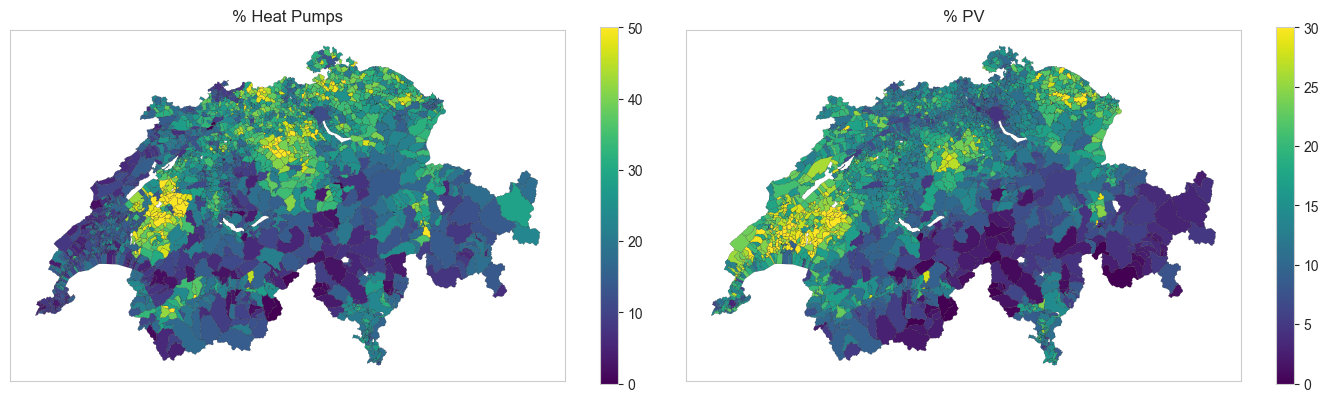

In [34]:
data_m = gdf.pivot_table(index='Municipality', columns='Heating Technology', aggfunc='size', fill_value=0)
data_percentage_m = data_m.div(data_m.sum(axis=1), axis=0) * 100
data_percentage_m = data_percentage_m.reset_index(drop=False)
data_percentage_m = data_percentage_m.merge(municipal_limits, how='left', left_on=['Municipality'], right_on=['NAME'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

data_HP_percentage_m = data_percentage_m[['Municipality', 'HeatPump', 'geometry']]
data_HP_percentage_m = data_HP_percentage_m.reset_index(drop=False)
gdf_HP_m = gpd.GeoDataFrame(data_HP_percentage_m, crs="EPSG:2056", geometry='geometry')
gdf_HP_m.plot(ax=axes[0], column='HeatPump', legend=True, linewidth=0.1, vmin=0, vmax=50, edgecolor='black', cmap='viridis').set_title('% Heat Pumps')
axes[0].set_xticks([])
axes[0].set_yticks([])

data_m = gdf.pivot_table(index='Municipality', columns='PV', aggfunc='size', fill_value=0)
data_percentage_m = data_m.div(data_m.sum(axis=1), axis=0) * 100
data_percentage_m = data_percentage_m.reset_index(drop=False)
data_percentage_m = data_percentage_m.merge(municipal_limits, how='left', left_on=['Municipality'], right_on=['NAME'])

data_PV_percentage_m = data_percentage_m[['Municipality', 'PVyes', 'geometry']]
data_PV_percentage_m = data_PV_percentage_m.reset_index(drop=False)
gdf_PV_m = gpd.GeoDataFrame(data_PV_percentage_m, crs="EPSG:2056", geometry='geometry')
gdf_PV_m.plot(ax=axes[1], column='PVyes', legend=True, linewidth=0.1, vmin=0, vmax=30, edgecolor='black', cmap='viridis').set_title('% PV')
axes[1].set_xticks([])
axes[1].set_yticks([])

plt.tight_layout()
plt.show()

In [35]:
gdf_regression = gdf_2025_drivers.drop(columns=['Heating Technology', 'PV', 'DH_binary']).copy()

Perform the chi-square test of independence between PV and HP for each combination of Canton, Type and Construction Period and check where a significant sign of dependence is present.

In [ ]:
def chi_sq_test(data, group_cols):
    """
    Perform chi-square test of independence between PV_binary and HP_binary
    within each combination of the specified group columns.
    """
    results = []

    for group_vals, df_group in data.groupby(group_cols, observed=False):
        ct = pd.crosstab(df_group["PV_binary"], df_group["HP_binary"])

        if ct.shape == (2, 2):
            chi2, p, dof, expected = chi2_contingency(ct)

            if isinstance(group_vals, tuple):
                group_dict = dict(zip(group_cols, group_vals))
            else:
                group_dict = {group_cols[0]: group_vals}

            results.append({
                **group_dict,
                "n_obs": len(df_group),
                "pv_rate": df_group["PV_binary"].mean(),
                "hp_rate": df_group["HP_binary"].mean(),
                "chi2": chi2,
                "p_value": p
            })

    return pd.DataFrame(results)

In [ ]:
res_3way = chi_sq_test(gdf_regression, ["Type", "Canton", "Construction Period"])
res_3way

## 3.1 District dummy variable

Perform the binary logit regression model for adoption of PV and HP at the building level, using dummy variables for each district. This leads to some dummy variables predictors for districts tobe not statistically significant.

One possible approach to deal with this problem is to cluster the dummy variables based on their values to have groups of municipalities with similar unobserved properties. the number of clusters is selected based on the Silhouette Scores (max value for different number of clusters).

Then perform again the regression with a dummy variable for each cluster of municipalities, and all the predictors are significant in the regression.

### 3.1.1 District dummy variable - PV

In [38]:
gdf_regression['Construction_Period'] = gdf_regression['Construction Period'].astype('category')
gdf_regression['Canton'] = gdf_regression['Canton'].astype('category')
gdf_regression['Municipality'] = gdf_regression['Municipality'].astype('category')
gdf_regression['District'] = gdf_regression['District'].astype('category')
gdf_regression['Area'] = gdf_regression['Area [m2]']
gdf_regression['log_Area'] = np.log(gdf_regression['Area'])
gdf_regression['Specific_Roof_Potential'] = gdf_regression['Specific Roof Potential [kWh/m2y]']
gdf_regression['Roof_area'] = gdf_regression['Roof area [m2]']
gdf_regression['Mean_Income'] = gdf_regression['Mean Income']
gdf_regression['EV_share'] = gdf_regression['EV share [%]']
gdf_regression['Secondary_House_Rate'] = gdf_regression['Secondary House Rate [%]']
gdf_regression['People_Over_65'] = gdf_regression['People Over 65 [%]']
gdf_regression['People_Over_80'] = gdf_regression['People Over 80 [%]']
gdf_regression['Households_Over_5_People'] = gdf_regression['Households Over 5 People [%]']
gdf_regression['Foreigners_Share'] = gdf_regression['Foreigners Share [%]']
gdf_regression['CO2Act_Yes_Share'] = gdf_regression['CO2Act Yes Share [%]']
gdf_regression['Population_Density'] = gdf_regression['Population Density']
gdf_regression['Electricity_Price'] = gdf_regression['Electricity Price (cts./kWh)']

cols_to_scale = ["log_Area", "Specific_Roof_Potential", "Roof_area", 'Mean_Income', 'EV_share', 'Population_Density', 'Secondary_House_Rate', 'Electricity_Price', 'Households_Over_5_People', 'People_Over_80', 'Foreigners_Share', 'CO2Act_Yes_Share', 'Population_Density']

scaler = StandardScaler()
gdf_regression[cols_to_scale] = scaler.fit_transform(gdf_regression[cols_to_scale])

formula = (
    "PV_binary ~ HP_binary + log_Area + Specific_Roof_Potential + Roof_area + Mean_Income + "
                "EV_share + Population_Density + Secondary_House_Rate + Electricity_Price + "
                "Households_Over_5_People + People_Over_80 + Foreigners_Share + CO2Act_Yes_Share + "
                "Population_Density +"
                "C(Type) + C(Construction_Period) + C(District)"
)

model_PV_dummy = smf.logit(formula=formula, data=gdf_regression).fit(maxiter=200)
print(model_PV_dummy.summary())

odds_ratios = model_PV_dummy.params.apply(lambda x: np.exp(x))
print("\nOdds Ratios:\n", odds_ratios)

Optimization terminated successfully.
         Current function value: 0.359712
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:              PV_binary   No. Observations:              1684337
Model:                          Logit   Df Residuals:                  1684171
Method:                           MLE   Df Model:                          165
Date:                Sun, 23 Nov 2025   Pseudo R-squ.:                  0.1060
Time:                        11:04:18   Log-Likelihood:            -6.0588e+05
converged:                       True   LL-Null:                   -6.7772e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------
Intercept                                   

In [39]:
district_effects_PV_d = model_PV_dummy.params.filter(like="C(District)")
district_se_PV_d = model_PV_dummy.bse.filter(like="C(District)")

PV_dummy_table = pd.DataFrame({
    "district": district_effects_PV_d.index.str.extract(r'T\.(.*)\]')[0],
    "coef": district_effects_PV_d.values,
    "se": district_se_PV_d.values,
    "z_value": district_effects_PV_d.values / district_se_PV_d.values,
    "p_value": 2 * (1 - norm.cdf(np.abs(district_effects_PV_d.values / district_se_PV_d.values)))
})

In [40]:
PV_dummy_table_merge = pd.merge(PV_dummy_table, limits, left_on="district", right_on='NAME')
PV_dummy_table_merge = gpd.GeoDataFrame(PV_dummy_table_merge, geometry='geometry')
PV_dummy_table_merge = PV_dummy_table_merge.to_crs(epsg=2056)

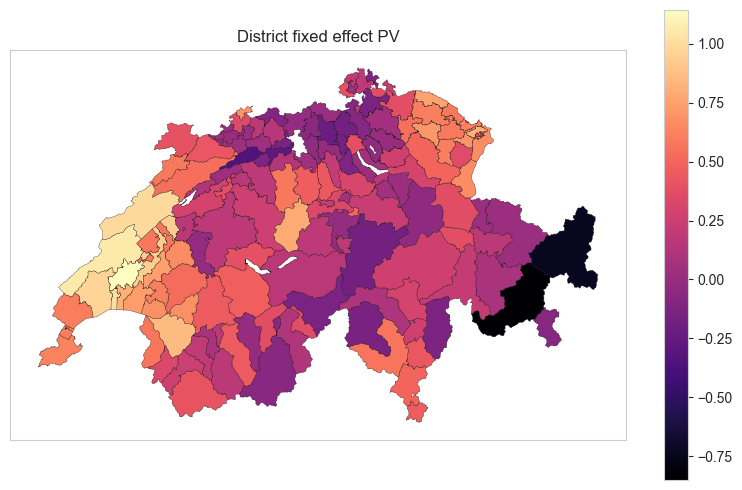

In [66]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

PV_dummy_table_merge.plot(ax=ax, column='coef', legend=True, linewidth=0.2, edgecolor='black', cmap='magma').set_title('District fixed effect PV')
ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()

In [42]:
alpha = 0.05
PV_dummy_table_merge["significant"] = PV_dummy_table_merge["p_value"] < alpha

n_non_significant = (PV_dummy_table_merge["significant"] == False).sum()
print("Non-significant districts:", n_non_significant)

Non-significant districts: 33


In [43]:
PV_dummy_vec = PV_dummy_table_merge["coef"].values.reshape(-1, 1)

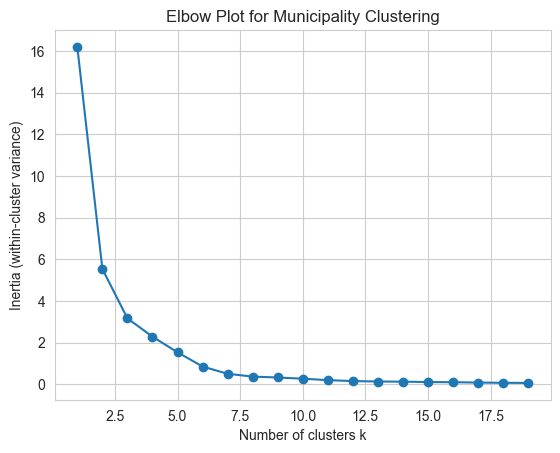

In [46]:
inertias = []
K_range = range(1, 20)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=0, n_init='auto').fit(PV_dummy_vec)
    inertias.append(km.inertia_)

plt.plot(K_range, inertias, marker='o')
plt.xlabel("Number of clusters k")
plt.ylabel("Inertia (within-cluster variance)")
plt.title("Elbow Plot for Municipality Clustering")
plt.grid(True)
plt.show()

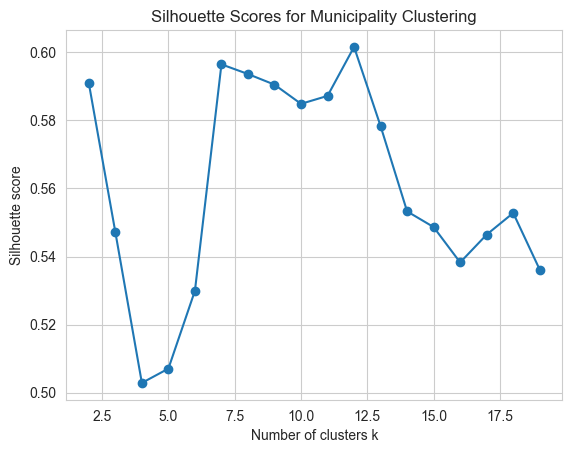

In [47]:
from sklearn.metrics import silhouette_score

sil_scores = []

for k in range(2, 20):
    km = KMeans(n_clusters=k, random_state=0, n_init='auto').fit(PV_dummy_vec)
    score = silhouette_score(PV_dummy_vec, km.labels_)
    sil_scores.append(score)

plt.plot(range(2, 20), sil_scores, marker='o')
plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette score")
plt.title("Silhouette Scores for Municipality Clustering")
plt.grid(True)
plt.show()

In [48]:
from sklearn.cluster import KMeans

k = 12  # choose based on elbow plot / AIC-like criteria
kmeans = KMeans(n_clusters=k, random_state=0).fit(PV_dummy_vec)

PV_dummy_table["cluster"] = kmeans.labels_

In [49]:
cluster_map = PV_dummy_table.set_index("district")["cluster"]
gdf_regression["district_cluster"] = gdf_regression["District"].map(cluster_map)
gdf_regression["district_cluster"] = gdf_regression["district_cluster"].astype("category")

In [50]:
formula = (
    "PV_binary ~ HP_binary + log_Area + Specific_Roof_Potential + "
                "Roof_area + Mean_Income + EV_share + Population_Density + "
                "Secondary_House_Rate + Electricity_Price + "
                "Households_Over_5_People + People_Over_80 + Foreigners_Share + "
                "CO2Act_Yes_Share + Population_Density +"
                "C(Type) + C(Construction_Period) + C(district_cluster)"
)

model_PV_dummy_cluster = smf.logit(formula=formula, data=gdf_regression).fit(maxiter=200)
print(model_PV_dummy_cluster.summary())

odds_ratios = model_PV_dummy_cluster.params.apply(lambda x: np.exp(x))
print("\nOdds Ratios:\n", odds_ratios)

Optimization terminated successfully.
         Current function value: 0.359893
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:              PV_binary   No. Observations:              1668300
Model:                          Logit   Df Residuals:                  1668265
Method:                           MLE   Df Model:                           34
Date:                Sun, 23 Nov 2025   Pseudo R-squ.:                  0.1061
Time:                        11:07:18   Log-Likelihood:            -6.0041e+05
converged:                       True   LL-Null:                   -6.7169e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Intercept                              -2.2425      0.012 

### 3.1.2 District dummy variable  - HP

In [51]:
gdf_regression['Construction_Period'] = gdf_regression['Construction Period'].astype('category')
gdf_regression['Canton'] = gdf_regression['Canton'].astype('category')
gdf_regression['Municipality'] = gdf_regression['Municipality'].astype('category')
gdf_regression['District'] = gdf_regression['District'].astype('category')
gdf_regression['Area'] = gdf_regression['Area [m2]']
gdf_regression['log_Area'] = np.log(gdf_regression['Area'])
gdf_regression['Specific_Roof_Potential'] = gdf_regression['Specific Roof Potential [kWh/m2y]']
gdf_regression['Roof_area'] = gdf_regression['Roof area [m2]']
gdf_regression['Mean_Income'] = gdf_regression['Mean Income']
gdf_regression['EV_share'] = gdf_regression['EV share [%]']
gdf_regression['Secondary_House_Rate'] = gdf_regression['Secondary House Rate [%]']
gdf_regression['People_Over_65'] = gdf_regression['People Over 65 [%]']
gdf_regression['People_Over_80'] = gdf_regression['People Over 80 [%]']
gdf_regression['Households_Over_5_People'] = gdf_regression['Households Over 5 People [%]']
gdf_regression['Foreigners_Share'] = gdf_regression['Foreigners Share [%]']
gdf_regression['CO2Act_Yes_Share'] = gdf_regression['CO2Act Yes Share [%]']
gdf_regression['Population_Density'] = gdf_regression['Population Density']
gdf_regression['Electricity_Price'] = gdf_regression['Electricity Price (cts./kWh)']

cols_to_scale = ["log_Area", 'Mean_Income', 'EV_share', 'Population_Density', 'Secondary_House_Rate', 'Electricity_Price', 'Households_Over_5_People', 'People_Over_80', 'Foreigners_Share', 'CO2Act_Yes_Share', 'Population_Density']

scaler = StandardScaler()
gdf_regression[cols_to_scale] = scaler.fit_transform(gdf_regression[cols_to_scale])

formula = (
    "HP_binary ~ PV_binary + log_Area + Mean_Income + EV_share + Population_Density + "
                "Secondary_House_Rate + Electricity_Price + Households_Over_5_People + "
                "People_Over_80 + Foreigners_Share + CO2Act_Yes_Share + Population_Density +"
                "C(Type) + C(Construction_Period) + C(District)"
)

model_HP_dummy = smf.logit(formula=formula, data=gdf_regression).fit(maxiter=200)
print(model_HP_dummy.summary())

# Odds ratios
odds_ratios = model_HP_dummy.params.apply(lambda x: np.exp(x))
print("\nOdds Ratios:\n", odds_ratios)

Optimization terminated successfully.
         Current function value: 0.425291
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:              HP_binary   No. Observations:              1684337
Model:                          Logit   Df Residuals:                  1684173
Method:                           MLE   Df Model:                          163
Date:                Sun, 23 Nov 2025   Pseudo R-squ.:                  0.2230
Time:                        11:09:39   Log-Likelihood:            -7.1633e+05
converged:                       True   LL-Null:                   -9.2187e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------
Intercept                                   

In [52]:
district_effects_HP_d = model_HP_dummy.params.filter(like="C(District)")
district_se_HP_d = model_HP_dummy.bse.filter(like="C(District)")

HP_dummy_table = pd.DataFrame({
    "district": district_effects_HP_d.index.str.extract(r'T\.(.*)\]')[0],
    "coef": district_effects_HP_d.values,
    "se": district_se_HP_d.values,
    "z_value": district_effects_HP_d.values / district_se_HP_d.values,
    "p_value": 2 * (1 - norm.cdf(np.abs(district_effects_HP_d.values / district_se_HP_d.values)))
})

In [53]:
HP_dummy_table_merge = pd.merge(HP_dummy_table, limits, left_on="district", right_on='NAME')
HP_dummy_table_merge = gpd.GeoDataFrame(HP_dummy_table_merge, geometry='geometry')
HP_dummy_table_merge = HP_dummy_table_merge.to_crs(epsg=2056)

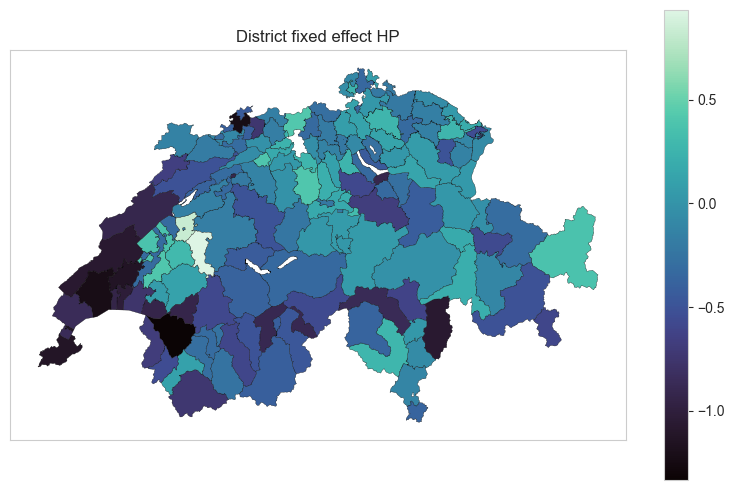

In [54]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

HP_dummy_table_merge.plot(ax=ax, column='coef', legend=True, linewidth=0.2, edgecolor='black', cmap='mako').set_title('District fixed effect HP')
ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()

In [55]:
alpha = 0.05
HP_dummy_table["significant"] = HP_dummy_table["p_value"] < alpha

n_non_significant = (HP_dummy_table["significant"] == False).sum()
print("Non-significant districts:", n_non_significant)
HP_dummy_vec = HP_dummy_table["coef"].values.reshape(-1, 1)

Non-significant districts: 21


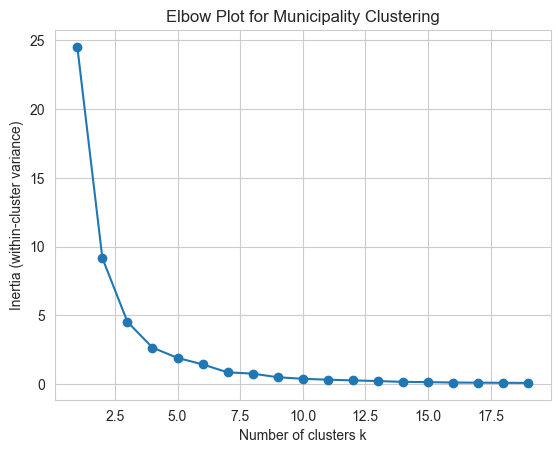

In [56]:
inertias = []
K_range = range(1, 20)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=0, n_init='auto').fit(HP_dummy_vec)
    inertias.append(km.inertia_)

plt.plot(K_range, inertias, marker='o')
plt.xlabel("Number of clusters k")
plt.ylabel("Inertia (within-cluster variance)")
plt.title("Elbow Plot for Municipality Clustering")
plt.grid(True)
plt.show()

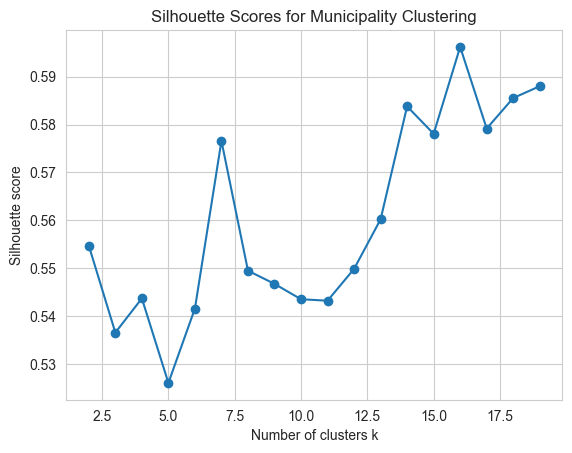

In [57]:
sil_scores = []

for k in range(2, 20):
    km = KMeans(n_clusters=k, random_state=0, n_init='auto').fit(HP_dummy_vec)
    score = silhouette_score(HP_dummy_vec, km.labels_)
    sil_scores.append(score)

plt.plot(range(2, 20), sil_scores, marker='o')
plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette score")
plt.title("Silhouette Scores for Municipality Clustering")
plt.grid(True)
plt.show()

In [58]:
k = 16
kmeans = KMeans(n_clusters=k, random_state=0).fit(HP_dummy_vec)

HP_dummy_table["cluster"] = kmeans.labels_

In [59]:
cluster_map = HP_dummy_table.set_index("district")["cluster"]
gdf_regression["district_cluster"] = gdf_regression["District"].map(cluster_map)
gdf_regression["district_cluster"] = gdf_regression["district_cluster"].astype("category")

In [60]:
formula = (
    "HP_binary ~ PV_binary + log_Area + Mean_Income + EV_share + Population_Density + "
                "Secondary_House_Rate + Electricity_Price + Households_Over_5_People + "
                "People_Over_80 + Foreigners_Share + CO2Act_Yes_Share + Population_Density +"
                "C(Type) + C(Construction_Period) + C(district_cluster)"
)

model_HP_dummy_cluster = smf.logit(formula=formula, data=gdf_regression).fit(maxiter=200)
print(model_HP_dummy_cluster.summary())

# Odds ratios
odds_ratios = model_HP_dummy_cluster.params.apply(lambda x: np.exp(x))
print("\nOdds Ratios:\n", odds_ratios)

Optimization terminated successfully.
         Current function value: 0.425141
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:              HP_binary   No. Observations:              1668300
Model:                          Logit   Df Residuals:                  1668263
Method:                           MLE   Df Model:                           36
Date:                Sun, 23 Nov 2025   Pseudo R-squ.:                  0.2225
Time:                        11:10:39   Log-Likelihood:            -7.0926e+05
converged:                       True   LL-Null:                   -9.1224e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Intercept                              -2.0742      0.011 

## 3.2 District random effect

Another possibility, instead of having the model with a dummy variable for each municipality:

log(odds) = β₀ + β₁*HP_binary + β₂*log_Area + ... + β_m*Municipality_m

is to have a mixed effect model:

log(odds) = β₀ + β₁*HP_binary + β₂*log_Area + ... + u_j

Where u_j is a random intercept for municipality j, and all u_j values are assumed to come from a common normal distribution: u_j ~ N(0, σ²).

This approach allows to have a BETTER generalization performance because dummy variables severely overfit and memorize geographical dependent noise.

It's important to notice that The u_j are NOT randomly assigned - they're optimally estimated based on the data, but with a crucial constraint. The model estimates:

- Fixed effects (β coefficients) for your main variables

- One variance parameter (σ²) that describes how much municipalities vary

For each municipality j, u_j is estimated as:

u_j = weighted average between:

- The municipality's own data: (mean outcome in municipality j)
- The global average: (overall fixed effects intercept)

The weighting depends on:

How many observations in municipality j (more data → trust municipality mean more)

How much municipalities vary overall (high variance → trust municipality mean more)

1. Apply this method to with district level resolution and compare the u_j obtained with the dummy variables seen before
2. Then, apply this method to the municipality level data

### 3.2.1 District random effect - PV

In [68]:
gdf_regression['Construction_Period'] = gdf_regression['Construction Period'].astype('category')
gdf_regression['Canton'] = gdf_regression['Canton'].astype('category')
gdf_regression['Municipality'] = gdf_regression['Municipality'].astype('category')
gdf_regression['District'] = gdf_regression['District'].astype('category')
gdf_regression['Area'] = gdf_regression['Area [m2]']
gdf_regression['log_Area'] = np.log(gdf_regression['Area'])
gdf_regression['Specific_Roof_Potential'] = gdf_regression['Specific Roof Potential [kWh/m2y]']
gdf_regression['Roof_area'] = gdf_regression['Roof area [m2]']
gdf_regression['Mean_Income'] = gdf_regression['Mean Income']
gdf_regression['EV_share'] = gdf_regression['EV share [%]']
gdf_regression['Secondary_House_Rate'] = gdf_regression['Secondary House Rate [%]']
gdf_regression['People_Over_65'] = gdf_regression['People Over 65 [%]']
gdf_regression['People_Over_80'] = gdf_regression['People Over 80 [%]']
gdf_regression['Households_Over_5_People'] = gdf_regression['Households Over 5 People [%]']
gdf_regression['Foreigners_Share'] = gdf_regression['Foreigners Share [%]']
gdf_regression['CO2Act_Yes_Share'] = gdf_regression['CO2Act Yes Share [%]']
gdf_regression['Population_Density'] = gdf_regression['Population Density']
gdf_regression['Electricity_Price'] = gdf_regression['Electricity Price (cts./kWh)']

cols_to_scale = ["log_Area", "Specific_Roof_Potential", "Roof_area", 'Mean_Income', 'EV_share', 'Population_Density', 'Secondary_House_Rate', 'Electricity_Price', 'Households_Over_5_People', 'People_Over_80', 'Foreigners_Share', 'CO2Act_Yes_Share', 'Population_Density']

scaler = StandardScaler()
gdf_regression[cols_to_scale] = scaler.fit_transform(gdf_regression[cols_to_scale])

formula = (
    "PV_binary ~ HP_binary + log_Area + Specific_Roof_Potential + Roof_area + "
                "Mean_Income + EV_share + Population_Density + Secondary_House_Rate + "
                "Electricity_Price + Households_Over_5_People + People_Over_80 + "
                "Foreigners_Share + CO2Act_Yes_Share + Population_Density +"
                "C(Type) + C(Construction_Period)"
)

model_mixed_district_PV = smf.mixedlm(
    formula=formula,
    data=gdf_regression,
    groups=gdf_regression["District"]
).fit()
print(model_mixed_district_PV.summary())

odds_ratios = model_mixed_district_PV.params.apply(lambda x: np.exp(x))
print("\nOdds Ratios:\n", odds_ratios)

C:\Users\matteo.palucci\OneDrive - SUPSI\Desktop\Tutto\Teaching\Project 1\SemesterProject\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


                     Mixed Linear Model Regression Results
Model:                   MixedLM        Dependent Variable:        PV_binary   
No. Observations:        1684337        Method:                    REML        
No. Groups:              143            Scale:                     0.1089      
Min. group size:         620            Log-Likelihood:            -522918.8237
Max. group size:         69792          Converged:                 Yes         
Mean group size:         11778.6                                               
-------------------------------------------------------------------------------
                                    Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------
Intercept                            0.072    0.003  22.728 0.000  0.066  0.079
C(Type)[T.MFH]                      -0.084    0.001 -84.593 0.000 -0.086 -0.082
C(Type)[T.SFH]                       0.004    0.001   4.561 0

In [69]:
random_effects_district_PV = model_mixed_district_PV.random_effects

district_re_PV = pd.DataFrame.from_dict(random_effects_district_PV, orient='index')
district_re_PV.index.name = 'District'
district_re_PV = district_re_PV.reset_index()

district_re_PV['Odds_Ratio'] = np.exp(district_re_PV['Group'])
district_re_PV['Rank'] = district_re_PV['Group'].rank(ascending=False)
district_re_PV = district_re_PV.sort_values('Group', ascending=False)

In [70]:
district_re_PV_merge = pd.merge(district_re_PV, limits, left_on="District", right_on='NAME')
district_re_PV_merge = gpd.GeoDataFrame(district_re_PV_merge, geometry='geometry')
district_re_PV_merge = district_re_PV_merge.to_crs(epsg=2056)

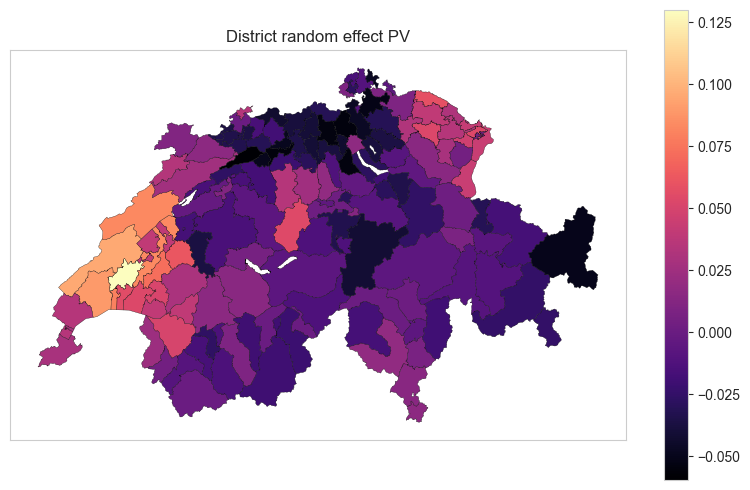

In [71]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

district_re_PV_merge.plot(ax=ax, column='Group', legend=True, linewidth=0.2, edgecolor='black', cmap='magma').set_title('District random effect PV')
ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()

### 3.2.2 District random effect - HP

In [72]:
gdf_regression['Construction_Period'] = gdf_regression['Construction Period'].astype('category')
gdf_regression['Canton'] = gdf_regression['Canton'].astype('category')
gdf_regression['Municipality'] = gdf_regression['Municipality'].astype('category')
gdf_regression['District'] = gdf_regression['District'].astype('category')
gdf_regression['Area'] = gdf_regression['Area [m2]']
gdf_regression['log_Area'] = np.log(gdf_regression['Area'])
gdf_regression['Specific_Roof_Potential'] = gdf_regression['Specific Roof Potential [kWh/m2y]']
gdf_regression['Roof_area'] = gdf_regression['Roof area [m2]']
gdf_regression['Mean_Income'] = gdf_regression['Mean Income']
gdf_regression['EV_share'] = gdf_regression['EV share [%]']
gdf_regression['Secondary_House_Rate'] = gdf_regression['Secondary House Rate [%]']
gdf_regression['People_Over_65'] = gdf_regression['People Over 65 [%]']
gdf_regression['People_Over_80'] = gdf_regression['People Over 80 [%]']
gdf_regression['Households_Over_5_People'] = gdf_regression['Households Over 5 People [%]']
gdf_regression['Foreigners_Share'] = gdf_regression['Foreigners Share [%]']
gdf_regression['CO2Act_Yes_Share'] = gdf_regression['CO2Act Yes Share [%]']
gdf_regression['Population_Density'] = gdf_regression['Population Density']
gdf_regression['Electricity_Price'] = gdf_regression['Electricity Price (cts./kWh)']

cols_to_scale = ["log_Area", 'Mean_Income', 'EV_share', 'Population_Density', 'Secondary_House_Rate', 'Electricity_Price', 'Households_Over_5_People', 'People_Over_80', 'Foreigners_Share', 'CO2Act_Yes_Share', 'Population_Density']

scaler = StandardScaler()
gdf_regression[cols_to_scale] = scaler.fit_transform(gdf_regression[cols_to_scale])

formula = (
    "HP_binary ~ PV_binary + log_Area + Mean_Income + EV_share + Population_Density + "
                "Secondary_House_Rate + Electricity_Price + Households_Over_5_People + "
                "People_Over_80 + Foreigners_Share + CO2Act_Yes_Share + Population_Density +"
                "C(Type) + C(Construction_Period)"
)

model_mixed = smf.mixedlm(
    formula=formula,
    data=gdf_regression,
    groups=gdf_regression["District"]
).fit()
print(model_mixed.summary())

odds_ratios = model_mixed.params.apply(lambda x: np.exp(x))
print("\nOdds Ratios:\n", odds_ratios)

C:\Users\matteo.palucci\OneDrive - SUPSI\Desktop\Tutto\Teaching\Project 1\SemesterProject\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


                     Mixed Linear Model Regression Results
Model:                   MixedLM        Dependent Variable:        HP_binary   
No. Observations:        1684337        Method:                    REML        
No. Groups:              143            Scale:                     0.1355      
Min. group size:         620            Log-Likelihood:            -707208.7757
Max. group size:         69792          Converged:                 Yes         
Mean group size:         11778.6                                               
-------------------------------------------------------------------------------
                                    Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------
Intercept                            0.112    0.005  22.380 0.000  0.102  0.121
C(Type)[T.MFH]                      -0.070    0.001 -63.018 0.000 -0.072 -0.068
C(Type)[T.SFH]                       0.007    0.001   7.524 0

In [73]:
random_effects = model_mixed.random_effects

district_re_HP = pd.DataFrame.from_dict(random_effects, orient='index')
district_re_HP.index.name = 'District'
district_re_HP = district_re_HP.reset_index()

district_re_HP['Odds_Ratio'] = np.exp(district_re_HP['Group'])
district_re_HP['Rank'] = district_re_HP['Group'].rank(ascending=False)
district_re_HP = district_re_HP.sort_values('Group', ascending=False)

In [74]:
district_re_HP_merge = pd.merge(district_re_HP, limits, left_on="District", right_on='NAME')
district_re_HP_merge = gpd.GeoDataFrame(district_re_HP_merge, geometry='geometry')
district_re_HP_merge = district_re_HP_merge.to_crs(epsg=2056)

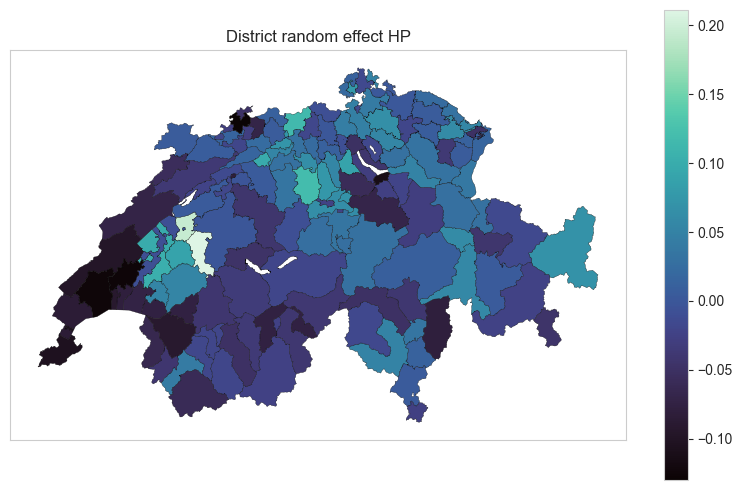

In [76]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

district_re_HP_merge.plot(ax=ax, column='Group', legend=True, linewidth=0.2, edgecolor='black', cmap='mako').set_title('District random effect HP')
ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()

## 3.3 Fixed vs Random effect comparison residuals

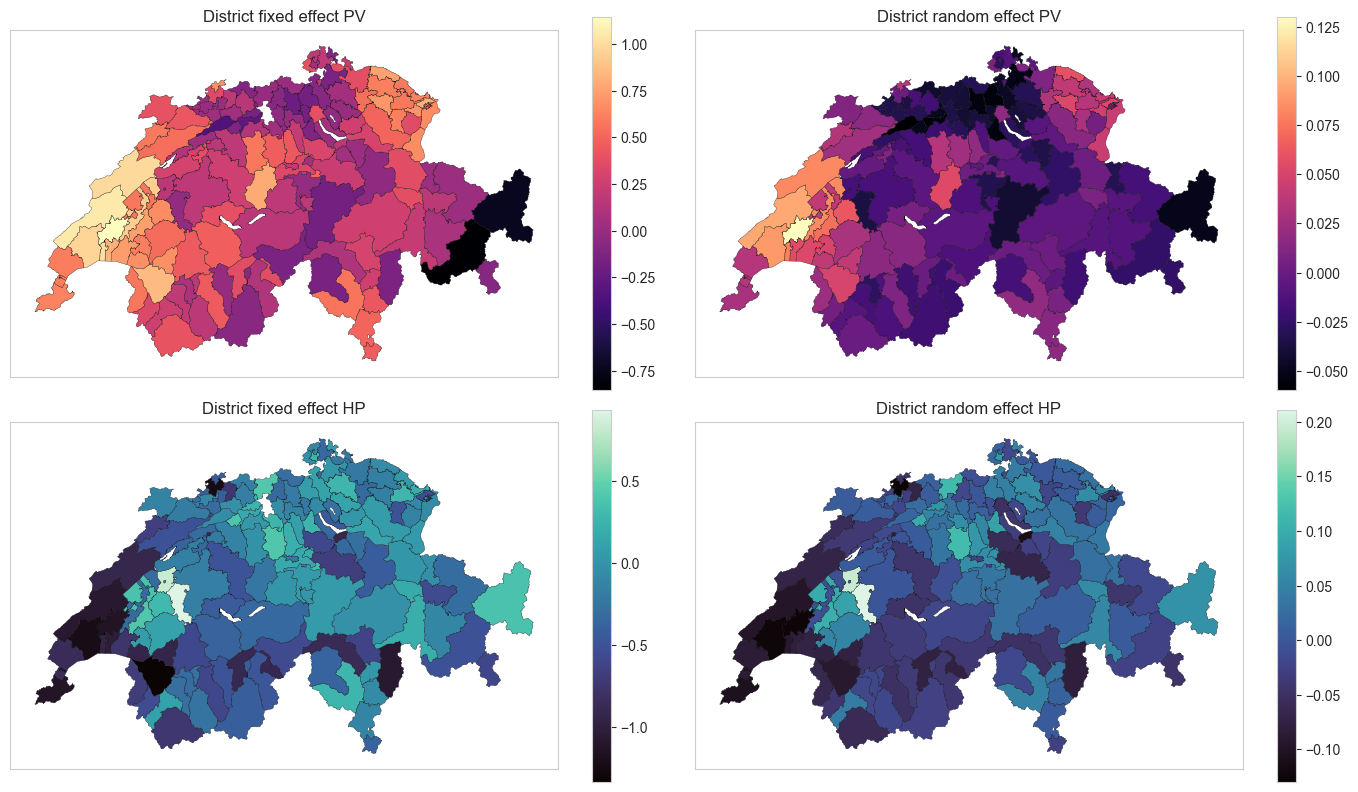

In [78]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

PV_dummy_table_merge.plot(ax=axes[0,0], column='coef', legend=True, linewidth=0.2, edgecolor='black', cmap='magma').set_title('District fixed effect PV')
axes[0,0].set_xticks([])
axes[0,0].set_yticks([])

HP_dummy_table_merge.plot(ax=axes[1,0], column='coef', legend=True, linewidth=0.2, edgecolor='black', cmap='mako').set_title('District fixed effect HP')
axes[1,0].set_xticks([])
axes[1,0].set_yticks([])

district_re_PV_merge.plot(ax=axes[0,1], column='Group', legend=True, linewidth=0.2, edgecolor='black', cmap='magma').set_title('District random effect PV')
axes[0,1].set_xticks([])
axes[0,1].set_yticks([])

district_re_HP_merge.plot(ax=axes[1,1], column='Group', legend=True, linewidth=0.2, edgecolor='black', cmap='mako').set_title('District random effect HP')
axes[1,1].set_xticks([])
axes[1,1].set_yticks([])

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'HP residuals')

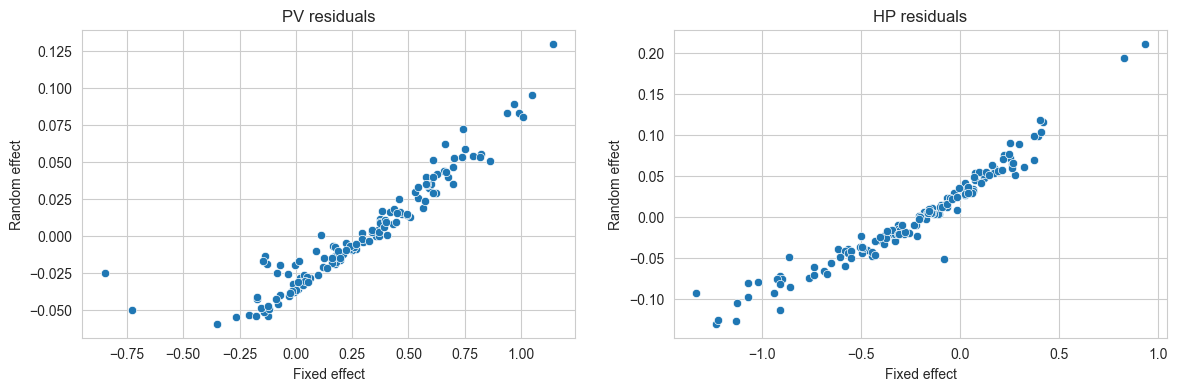

In [122]:
merge_PV = pd.merge(PV_dummy_table_merge, district_re_PV_merge, left_on="district", right_on='District')
merge_PV = merge_PV.rename(columns={'coef': 'Fixed effect', 'Group': 'Random effect'})
merge_HP = pd.merge(HP_dummy_table_merge, district_re_HP_merge, left_on="district", right_on='District')
merge_HP = merge_HP.rename(columns={'coef': 'Fixed effect', 'Group': 'Random effect'})

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.scatterplot(ax=axes[0], data=merge_PV, x="Fixed effect", y="Random effect").set_title('PV residuals')
sns.scatterplot(ax=axes[1], data=merge_HP, x="Fixed effect", y="Random effect").set_title('HP residuals')

## 3.3 Municipality random effect

### 3.3.1 Municipality Random effect - PV

In [90]:
gdf_regression['Construction_Period'] = gdf_regression['Construction Period'].astype('category')
gdf_regression['Canton'] = gdf_regression['Canton'].astype('category')
gdf_regression['Municipality'] = gdf_regression['Municipality'].astype('category')
gdf_regression['District'] = gdf_regression['District'].astype('category')
gdf_regression['Area'] = gdf_regression['Area [m2]']
gdf_regression['log_Area'] = np.log(gdf_regression['Area'])
gdf_regression['Specific_Roof_Potential'] = gdf_regression['Specific Roof Potential [kWh/m2y]']
gdf_regression['Roof_area'] = gdf_regression['Roof area [m2]']
gdf_regression['Mean_Income'] = gdf_regression['Mean Income']
gdf_regression['EV_share'] = gdf_regression['EV share [%]']
gdf_regression['Secondary_House_Rate'] = gdf_regression['Secondary House Rate [%]']
gdf_regression['People_Over_65'] = gdf_regression['People Over 65 [%]']
gdf_regression['People_Over_80'] = gdf_regression['People Over 80 [%]']
gdf_regression['Households_Over_5_People'] = gdf_regression['Households Over 5 People [%]']
gdf_regression['Foreigners_Share'] = gdf_regression['Foreigners Share [%]']
gdf_regression['CO2Act_Yes_Share'] = gdf_regression['CO2Act Yes Share [%]']
gdf_regression['Population_Density'] = gdf_regression['Population Density']
gdf_regression['Electricity_Price'] = gdf_regression['Electricity Price (cts./kWh)']

cols_to_scale = ["log_Area", "Specific_Roof_Potential", "Roof_area", 'Mean_Income', 'EV_share', 'Population_Density', 'Secondary_House_Rate', 'Electricity_Price', 'Households_Over_5_People', 'People_Over_80', 'Foreigners_Share', 'CO2Act_Yes_Share', 'Population_Density']

scaler = StandardScaler()
gdf_regression[cols_to_scale] = scaler.fit_transform(gdf_regression[cols_to_scale])

formula = (
    "PV_binary ~ HP_binary + log_Area + Specific_Roof_Potential + Roof_area + "
                "C(Type) + C(Construction_Period)"
)

model_mixed = smf.mixedlm(
    formula=formula,
    data=gdf_regression,
    groups=gdf_regression["Municipality"]
).fit()
print(model_mixed.summary())

odds_ratios = model_mixed.params.apply(lambda x: np.exp(x))
print("\nOdds Ratios:\n", odds_ratios)

C:\Users\matteo.palucci\OneDrive - SUPSI\Desktop\Tutto\Teaching\Project 1\SemesterProject\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


                     Mixed Linear Model Regression Results
Model:                   MixedLM        Dependent Variable:        PV_binary   
No. Observations:        1684337        Method:                    REML        
No. Groups:              2116           Scale:                     0.1084      
Min. group size:         2              Log-Likelihood:            -521600.7984
Max. group size:         33800          Converged:                 Yes         
Mean group size:         796.0                                                 
-------------------------------------------------------------------------------
                                    Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------
Intercept                            0.083    0.002  53.572 0.000  0.080  0.086
C(Type)[T.MFH]                      -0.084    0.001 -84.038 0.000 -0.086 -0.082
C(Type)[T.SFH]                       0.005    0.001   5.508 0

In [91]:
random_effects = model_mixed.random_effects

municipality_re_PV = pd.DataFrame.from_dict(random_effects, orient='index')
municipality_re_PV.index.name = 'Municipality'
municipality_re_PV = municipality_re_PV.reset_index()

municipality_re_PV['Odds_Ratio'] = np.exp(municipality_re_PV['Group'])
municipality_re_PV['Rank'] = municipality_re_PV['Group'].rank(ascending=False)
municipality_re_PV = municipality_re_PV.sort_values('Group', ascending=False)

In [92]:
municipality_re_PV_merge = pd.merge(municipality_re_PV, municipal_limits, left_on="Municipality", right_on='NAME')
municipality_re_PV_merge = gpd.GeoDataFrame(municipality_re_PV_merge, geometry='geometry')
municipality_re_PV_merge = municipality_re_PV_merge.to_crs(epsg=2056)

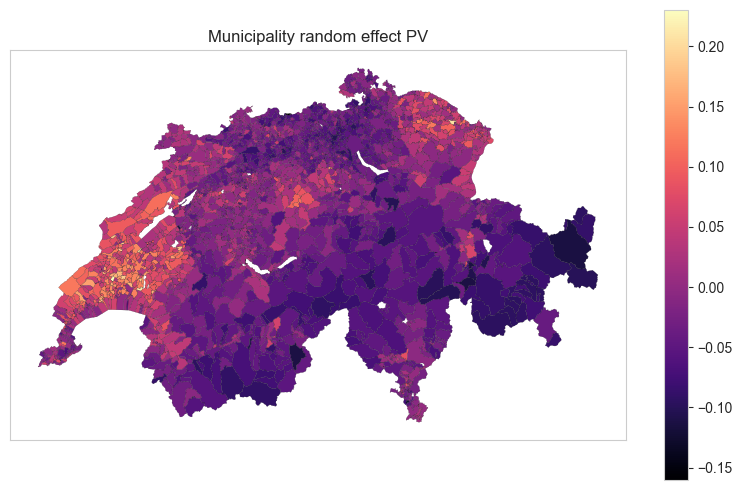

In [93]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

municipality_re_PV_merge.plot(ax=ax, column='Group', legend=True, linewidth=0.1, edgecolor='black', cmap='magma').set_title('Municipality random effect PV')
ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()

### 3.3.2 Municipality Random effect - HP

In [94]:
gdf_regression['Construction_Period'] = gdf_regression['Construction Period'].astype('category')
gdf_regression['Canton'] = gdf_regression['Canton'].astype('category')
gdf_regression['Municipality'] = gdf_regression['Municipality'].astype('category')
gdf_regression['District'] = gdf_regression['District'].astype('category')
gdf_regression['Area'] = gdf_regression['Area [m2]']
gdf_regression['log_Area'] = np.log(gdf_regression['Area'])
gdf_regression['Specific_Roof_Potential'] = gdf_regression['Specific Roof Potential [kWh/m2y]']
gdf_regression['Roof_area'] = gdf_regression['Roof area [m2]']
gdf_regression['Mean_Income'] = gdf_regression['Mean Income']
gdf_regression['EV_share'] = gdf_regression['EV share [%]']
gdf_regression['Secondary_House_Rate'] = gdf_regression['Secondary House Rate [%]']
gdf_regression['People_Over_65'] = gdf_regression['People Over 65 [%]']
gdf_regression['People_Over_80'] = gdf_regression['People Over 80 [%]']
gdf_regression['Households_Over_5_People'] = gdf_regression['Households Over 5 People [%]']
gdf_regression['Foreigners_Share'] = gdf_regression['Foreigners Share [%]']
gdf_regression['CO2Act_Yes_Share'] = gdf_regression['CO2Act Yes Share [%]']
gdf_regression['Population_Density'] = gdf_regression['Population Density']
gdf_regression['Electricity_Price'] = gdf_regression['Electricity Price (cts./kWh)']

cols_to_scale = ["log_Area"]

scaler = StandardScaler()
gdf_regression[cols_to_scale] = scaler.fit_transform(gdf_regression[cols_to_scale])

formula = (
    "HP_binary ~ PV_binary + log_Area + "
                "C(Type) + C(Construction_Period)"
)

model_mixed = smf.mixedlm(
    formula=formula,
    data=gdf_regression,
    groups=gdf_regression["Municipality"]
).fit()
print(model_mixed.summary())

odds_ratios = model_mixed.params.apply(lambda x: np.exp(x))
print("\nOdds Ratios:\n", odds_ratios)

C:\Users\matteo.palucci\OneDrive - SUPSI\Desktop\Tutto\Teaching\Project 1\SemesterProject\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\matteo.palucci\OneDrive - SUPSI\Desktop\Tutto\Teaching\Project 1\SemesterProject\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
C:\Users\matteo.palucci\OneDrive - SUPSI\Desktop\Tutto\Teaching\Project 1\SemesterProject\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\matteo.palucci\OneDrive - SUPSI\Desktop\Tutto\Teaching\Project 1\SemesterProject\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: 

                     Mixed Linear Model Regression Results
Model:                   MixedLM        Dependent Variable:        HP_binary   
No. Observations:        1684337        Method:                    REML        
No. Groups:              2116           Scale:                     0.1332      
Min. group size:         2              Log-Likelihood:            -695559.6438
Max. group size:         33800          Converged:                 No          
Mean group size:         796.0                                                 
-------------------------------------------------------------------------------
                                    Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------
Intercept                            0.111    0.002  60.186 0.000  0.107  0.114
C(Type)[T.MFH]                      -0.068    0.001 -61.196 0.000 -0.070 -0.065
C(Type)[T.SFH]                       0.007    0.001   7.590 0

In [95]:
random_effects = model_mixed.random_effects

municipality_re_HP = pd.DataFrame.from_dict(random_effects, orient='index')
municipality_re_HP.index.name = 'Municipality'
municipality_re_HP = municipality_re_HP.reset_index()

municipality_re_HP['Odds_Ratio'] = np.exp(municipality_re_HP['Group'])
municipality_re_HP['Rank'] = municipality_re_HP['Group'].rank(ascending=False)
municipality_re_HP = municipality_re_HP.sort_values('Group', ascending=False)

In [96]:
municipality_re_HP_merge = pd.merge(municipality_re_HP, municipal_limits, left_on="Municipality", right_on='NAME')
municipality_re_HP_merge = gpd.GeoDataFrame(municipality_re_HP_merge, geometry='geometry')
municipality_re_HP_merge = municipality_re_HP_merge.to_crs(epsg=2056)

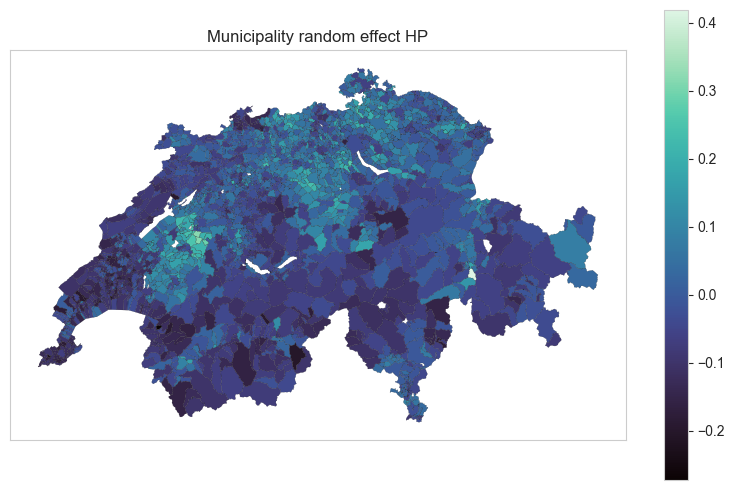

In [123]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

municipality_re_HP_merge.plot(ax=ax, column='Group', legend=True, linewidth=0.1, edgecolor='black', cmap='mako').set_title('Municipality random effect HP')
ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()

Text(0.5, 1.0, 'PV-HP residuals')

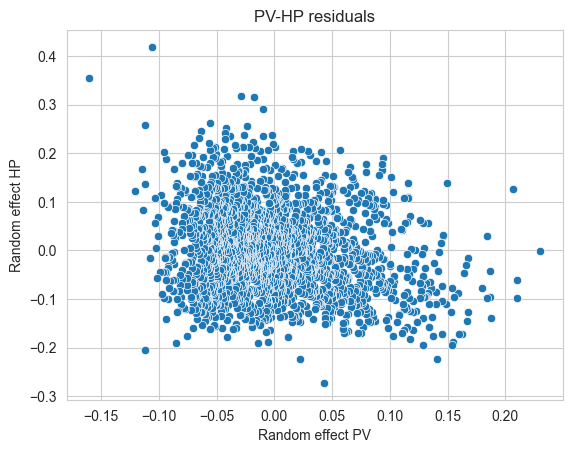

In [132]:
merge_PV_HP = pd.merge(municipality_re_PV_merge, municipality_re_HP_merge, on="Municipality")
merge_PV_HP = merge_PV_HP.rename(columns={'Group_x': 'Random effect PV', 'Group_y': 'Random effect HP'})

sns.scatterplot(data=merge_PV_HP, x="Random effect PV", y="Random effect HP").set_title('PV-HP residuals')

In [131]:
merge_PV_HP.head()

,Municipality,Random effect PV,Odds_Ratio_x,Rank_x,NAME_x,geometry_x,Random effect HP,Odds_Ratio_y,Rank_y,NAME_y,geometry_y
0,Daillens,0.230271,1.258942,1.0,Daillens,"POLYGON Z ((2530410.907 1164181.379 439.476, 2...",-0.000298,0.999702,1000.0,Daillens,"POLYGON Z ((2530410.907 1164181.379 439.476, 2..."
1,Rovray,0.210355,1.234116,2.0,Rovray,"POLYGON Z ((2548365.406 1180764.453 524.6, 254...",-0.060443,0.941347,1571.0,Rovray,"POLYGON Z ((2548365.406 1180764.453 524.6, 254..."
2,Servion,0.209927,1.233589,3.0,Servion,"POLYGON Z ((2549181.26 1156907.834 812.826, 25...",-0.098014,0.906636,1849.0,Servion,"POLYGON Z ((2549181.26 1156907.834 812.826, 25..."
3,Häggenschwil,0.206546,1.229424,4.0,Häggenschwil,MULTIPOLYGON Z (((2745350.64 1261788.758 581.0...,0.126099,1.134395,175.0,Häggenschwil,MULTIPOLYGON Z (((2745350.64 1261788.758 581.0...
4,Echallens,0.187494,1.206223,5.0,Echallens,"POLYGON Z ((2536799.038 1166156.651 590.755, 2...",-0.139052,0.870183,2038.0,Echallens,"POLYGON Z ((2536799.038 1166156.651 590.755, 2..."
